# CCNLP CCA1 — Identifying Marathi Proverbs: Literal vs. Culturally Intended Figurative Meaning

**Group 16** &nbsp;|&nbsp; Panel B &nbsp;|&nbsp; School of Computer Science & Engineering, MIT-WPU

| Member | PRN | Language Scope |
|---|---|---|
| ** Sahish Nagulwar ** | ** 1032233310 ** | ** Marathi (this notebook) ** |
|  Ibrahim Ansari  |  1032233145  |  Hindi  |
| Chayan Raj Bharati | 1032233134 | Assamese |

**Team problem statement:** *Develop a multilingual NLP framework that identifies Indian idioms and distinguishes their literal meaning from culturally intended figurative meaning across Indian languages, while modeling cultural context and linguistic variation.*

**Individual scope (Sahish Nagulwar):** Marathi proverbs and idiomatic sayings, using a book-derived corpus.

## Research Question
> RQ: How accurately can the figurative theme of a Marathi proverb be predicted from its literal text alone, and how well does lexical retrieval link a proverb to its intended explanation when the query is in English and when it is in romanized Marathi?

## Research Contribution
The main output of this work is a machine-readable corpus of 545 Marathi proverbs taken from Manwaring (1899). Each entry has the romanized Marathi text, a literal English translation, the compiler's explanation of the intended meaning (349 entries) and the book's section heading as a theme label. The extraction uses the same pipeline as the other two tracks. The corpus is then used for two experiments: theme classification from the surface text, and retrieval of the correct explanation for a given proverb, with TF-IDF as the lexical method and LaBSE/MuRIL as the multilingual condition.

## Methodology
The corpus is built from the Internet Archive OCR of Manwaring (1899). Section page-headers give the theme labels. Inside each entry, the romanized Marathi line is found by its low share of common English function words. The block after it is split at the first sentence boundary: the first sentence is the literal translation and the rest is the explanation. OCR junk is trimmed off. Two experiments follow. Theme classification runs over the 13 sections that have at least 12 proverbs (the book's "Unclassified" section is left out), with logistic regression and balanced class weights, once with word TF-IDF on the literal translations and once with character 2-4-gram TF-IDF on the romanized Marathi, under stratified 5-fold CV. Retrieval runs over the 349 entries that have explanations: explanations are ranked by TF-IDF cosine for English-literal and for romanized-Marathi queries, scored with P@k and MRR, and a LaBSE condition is included.


## 1. Corpus Description

**Source (book, public domain):** Manwaring, A. (1899). *Marathi Proverbs.* Oxford: Clarendon Press. Internet Archive: https://archive.org/details/marathiproverbs00manwgoog

A collection of about 1,900 Marathi proverbs arranged in subject sections (Agriculture, Animals, Ethical, Religious, Nature and others). Each entry prints the Devanagari original, a romanized transliteration, a literal English translation and, for most entries, the compiler's explanation of the intended meaning. The corpus was extracted with `PanelB_16_extract_marathi.py`. The raw OCR source is kept at `corpus/PanelB_16_marathi_manwaring1899_raw.txt`. The book's section headings are used as theme labels.

**Corpus size and why:** the book prints about 1,900 proverbs and the extractor kept 545. An entry was accepted only when the romanized line and the translation could be recovered cleanly from the OCR and a section heading was in scope. Damaged entries were dropped rather than patched, since the experiments need clean paired fields. This is the largest corpus of the three tracks, which matches the source: the Clarendon Press print gives the best OCR of the three books.

**Fields:** `theme` / `theme_bucket` (figurative class where available), `proverb_translit` (romanized Marathi), `literal_en` (literal translation), `commentary` (culturally intended figurative explanation).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os

sns.set_theme(style='whitegrid')
metrics = {}
df = pd.read_csv('corpus/PanelB_16_marathi_proverbs.csv')
metrics['n'] = len(df)
metrics['n_comm'] = int((df.commentary.fillna('').str.len() > 15).sum())
print(f"Proverbs: {metrics['n']}, with figurative explanation: {metrics['n_comm']}")
df.head(3)

Proverbs: 545, with figurative explanation: 349


,id,theme,theme_bucket,proverb_translit,literal_en,commentary
0,6,Agriculture,agriculture,Kanda ani mardStsa baiidha,"The ottion is inform like a man, i e. stout an...",KonkaDaiita narala pbukata milatata Cocoa-nuts...
1,7,Agriculture,agriculture,KliaDdiDiadhye pava rati,An ounce »hort in a cart-load.,Why trouble abont so trivial a matter?
2,8,Agriculture,agriculture,Zalata ghara bhadyane va zune zondhale kadhyane,gheu naye Do not hire a burning house and do n...,It is usual to pay back one and a quarter or o...


In [2]:
df['translit_tokens'] = df.proverb_translit.str.split().str.len()
df['literal_tokens'] = df.literal_en.str.split().str.len()
df['commentary_tokens'] = df.commentary.fillna('').str.split().str.len()

vocab_src = set(w.lower() for t in df.proverb_translit for w in t.split())
vocab_en = set(w.lower() for t in df.literal_en for w in t.split())
metrics.update(tok_src=int(df.translit_tokens.sum()), tok_en=int(df.literal_tokens.sum()),
               tok_comm=int(df.commentary_tokens.sum()), voc_src=len(vocab_src), voc_en=len(vocab_en),
               len_src=round(float(df.translit_tokens.mean()),1), len_en=round(float(df.literal_tokens.mean()),1),
               len_comm=round(float(df.commentary_tokens.mean()),1))
pd.DataFrame({'Source (romanized)': [metrics['tok_src'], metrics['voc_src'], metrics['len_src']],
              'Literal English': [metrics['tok_en'], metrics['voc_en'], metrics['len_en']],
              'Figurative explanation': [metrics['tok_comm'], np.nan, metrics['len_comm']]},
             index=['total tokens', 'vocabulary size', 'avg tokens/proverb'])

,Source (romanized),Literal English,Figurative explanation
total tokens,2670.0,11915.0,5575.0
vocabulary size,2066.0,6442.0,NaN
avg tokens/proverb,4.9,21.9,10.2


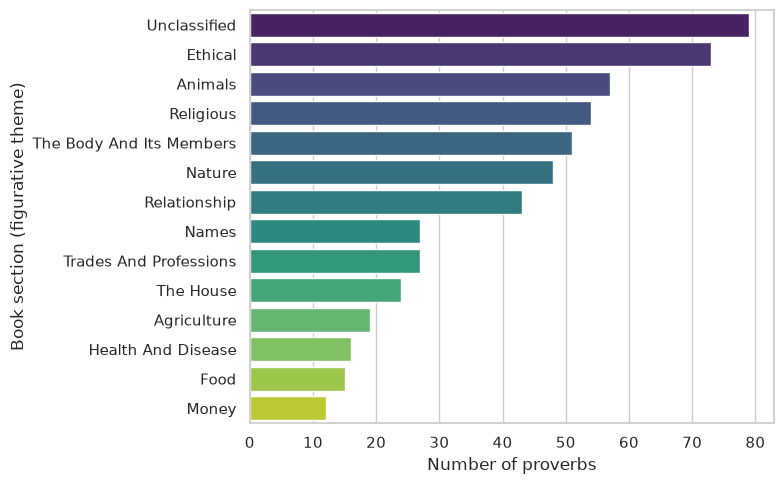

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.theme.value_counts()
sns.barplot(x=order.values, y=order.index, hue=order.index, palette='viridis', legend=False, ax=ax)
ax.set_xlabel('Number of proverbs'); ax.set_ylabel("Book section (figurative theme)")
plt.tight_layout(); plt.show()

**Figure 1: Number of proverbs in each of the book's subject sections.**

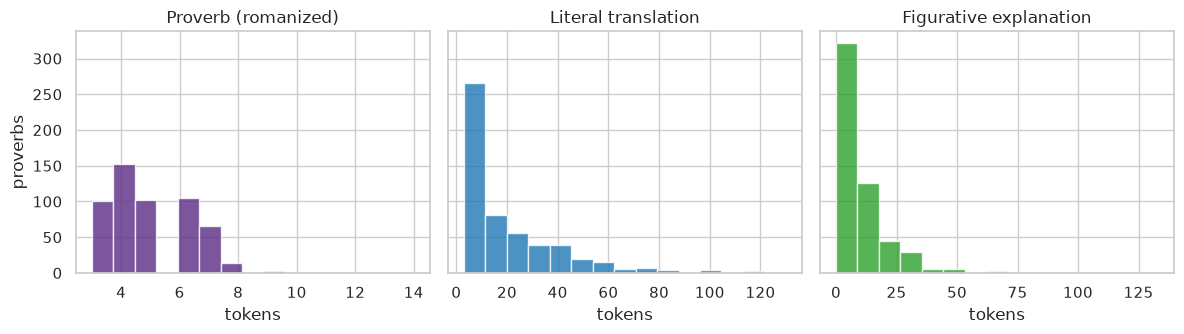

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, col, name, c in zip(axes, ['translit_tokens', 'literal_tokens', 'commentary_tokens'],
        ['Proverb (romanized)', 'Literal translation', 'Figurative explanation'],
        ['#5b2c83', '#1f77b4', '#2ca02c']):
    ax.hist(df[col], bins=15, color=c, alpha=0.8); ax.set_title(name); ax.set_xlabel('tokens')
axes[0].set_ylabel('proverbs')
plt.tight_layout(); plt.show()

**Figure 2: Token-length distributions for the proverb, its literal translation, and the explanation.**

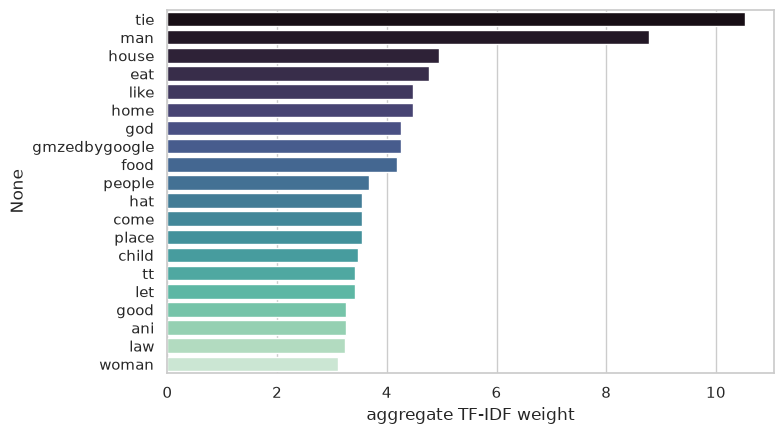

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(stop_words='english', max_features=4000)
X = vec.fit_transform(df.literal_en)
terms = np.array(vec.get_feature_names_out())
top = pd.Series(np.asarray(X.sum(axis=0)).ravel(), index=terms).nlargest(20)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=top.values, y=top.index, hue=top.index, palette='mako', legend=False, ax=ax)
ax.set_xlabel('aggregate TF-IDF weight')
plt.tight_layout(); plt.show()

**Figure 3: Top TF-IDF terms in the literal translations.**

## 2. Literal vs figurative: lexical gap
If the intended meaning could be read off the surface words, the literal translation and its explanation would share vocabulary. To check this we measure the Jaccard token overlap between them.

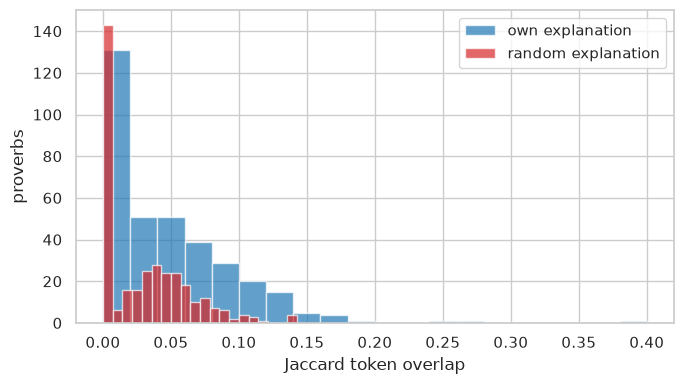

own: 0.046, random: 0.03


In [6]:
def jaccard(a, b):
    A = set(str(a).lower().split()); B = set(str(b).lower().split())
    return len(A & B) / len(A | B) if A | B else 0.0

has_comm = df[df.commentary.fillna('').str.len() > 15].reset_index(drop=True)
has_comm['overlap_own'] = [jaccard(r.literal_en, r.commentary) for r in has_comm.itertuples()]
rng = np.random.default_rng(42)
has_comm['overlap_random'] = [jaccard(r.literal_en, has_comm.commentary[rng.choice(len(has_comm))])
                              for r in has_comm.itertuples()]
metrics['jac_own'] = round(float(has_comm.overlap_own.mean()), 3)
metrics['jac_rand'] = round(float(has_comm.overlap_random.mean()), 3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(has_comm.overlap_own, bins=20, alpha=0.7, label='own explanation', color='#1f77b4')
ax.hist(has_comm.overlap_random, bins=20, alpha=0.7, label='random explanation', color='#d62728')
ax.set_xlabel('Jaccard token overlap'); ax.set_ylabel('proverbs'); ax.legend()
plt.tight_layout(); plt.show()
print(f"own: {metrics['jac_own']}, random: {metrics['jac_rand']}")

**Figure 4: Jaccard overlap between each proverb's literal translation and its own explanation, compared with a random explanation.**

## 3. Model 1: figurative theme classification
Here we predict the book section from (a) the literal English translation with word TF-IDF and (b) the romanized Marathi with character n-gram TF-IDF. Logistic regression, stratified 5-fold CV. The book's catch-all "Unclassified" section is left out.

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, confusion_matrix

keep = df[df.theme != 'Unclassified'].theme.value_counts()
keep = keep[keep >= 12].index
clf_df = df[df.theme.isin(keep)].reset_index(drop=True)
y = clf_df.theme
cv = StratifiedKFold(5, shuffle=True, random_state=42)

pipe_en = make_pipeline(TfidfVectorizer(stop_words='english', sublinear_tf=True),
                        LogisticRegression(max_iter=2000, class_weight='balanced'))
pipe_src = make_pipeline(TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4), sublinear_tf=True),
                         LogisticRegression(max_iter=2000, class_weight='balanced'))

acc_en = cross_val_score(pipe_en, clf_df.literal_en, y, cv=cv).mean()
acc_src = cross_val_score(pipe_src, clf_df.proverb_translit, y, cv=cv).mean()
pred_en = cross_val_predict(pipe_en, clf_df.literal_en, y, cv=cv)
pred_src = cross_val_predict(pipe_src, clf_df.proverb_translit, y, cv=cv)
maj_pred = pd.Series(y.value_counts().idxmax(), index=y.index)

metrics.update(clf_n=len(clf_df), clf_k=int(y.nunique()),
    maj_acc=round(float(y.value_counts(normalize=True).iloc[0]), 3),
    maj_f1=round(float(f1_score(y, maj_pred, average='macro')), 3),
    acc_en=round(float(acc_en), 3), f1_en=round(float(f1_score(y, pred_en, average='macro')), 3),
    acc_src=round(float(acc_src), 3), f1_src=round(float(f1_score(y, pred_src, average='macro')), 3))
print(f"{metrics['clf_n']} proverbs, {metrics['clf_k']} classes")
print(f"majority baseline:      acc={metrics['maj_acc']}  macro-F1={metrics['maj_f1']}")
print(f"EN word TF-IDF:         acc={metrics['acc_en']}  macro-F1={metrics['f1_en']}")
print(f"Marathi char TF-IDF:    acc={metrics['acc_src']}  macro-F1={metrics['f1_src']}")

466 proverbs, 13 classes
majority baseline:      acc=0.157  macro-F1=0.021
EN word TF-IDF:         acc=0.307  macro-F1=0.255
Marathi char TF-IDF:    acc=0.217  macro-F1=0.187


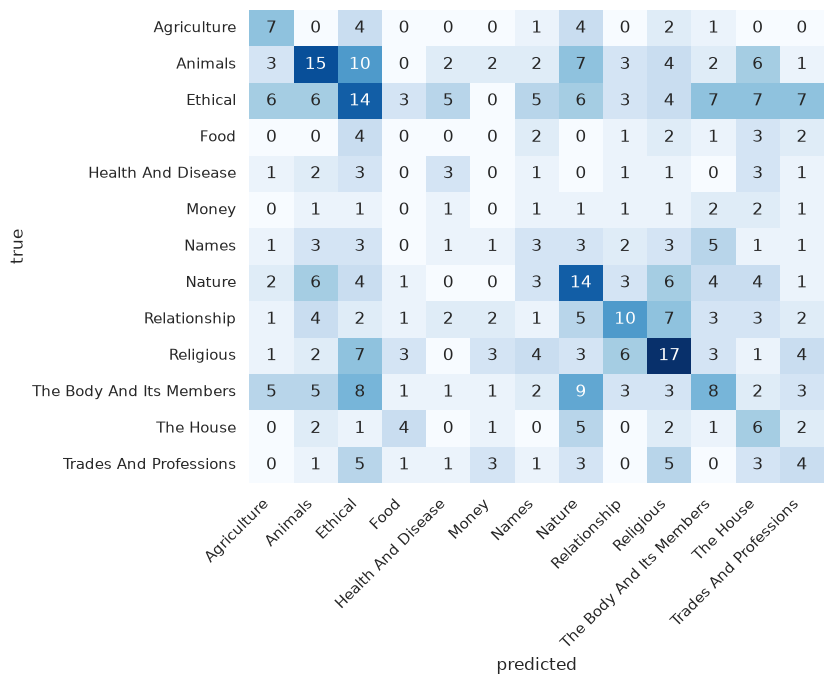

In [8]:
labels = sorted(y.unique())
cm = confusion_matrix(y, pred_src, labels=labels)
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

**Figure 5: Confusion matrix (cross-validated) for theme classification from the romanized Marathi text.**

## 4. Model 2: literal to figurative retrieval
For every proverb we rank all explanations by cosine similarity to the query and check where the correct one lands. The query is the literal translation in the first condition and the romanized Marathi text in the second, which is the cross-lingual case.

In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def retrieval_scores(sim):
    ranks = []
    for i in range(sim.shape[0]):
        order = np.argsort(-sim[i])
        ranks.append(int(np.where(order == i)[0][0]) + 1)
    ranks = np.array(ranks)
    return {'P@1': round(float((ranks == 1).mean()), 3),
            'P@5': round(float((ranks <= 5).mean()), 3),
            'MRR': round(float((1 / ranks).mean()), 3)}

vec_r = TfidfVectorizer(stop_words='english', sublinear_tf=True)
docs = vec_r.fit_transform(has_comm.commentary)
res = {}
res['TF-IDF (EN literal query)'] = retrieval_scores(cosine_similarity(vec_r.transform(has_comm.literal_en), docs))
res['TF-IDF (source-language query)'] = retrieval_scores(cosine_similarity(vec_r.transform(has_comm.proverb_translit), docs))
n = len(has_comm)
res['Random baseline'] = {'P@1': round(1/n, 3), 'P@5': round(5/n, 3),
                          'MRR': round(float(np.mean([1/r for r in range(1, n+1)])), 3)}
metrics['retrieval'] = res
metrics['n_retr'] = n
pd.DataFrame(res).T

,P@1,P@5,MRR
TF-IDF (EN literal query),0.129,0.212,0.174
TF-IDF (source-language query),0.029,0.046,0.047
Random baseline,0.003,0.014,0.018


In [10]:
# Multilingual transformer condition (LaBSE). Run on Colab if
# sentence-transformers is not installed locally.
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer('sentence-transformers/LaBSE')
    q_en = model.encode(list(has_comm.literal_en), show_progress_bar=False)
    q_src = model.encode(list(has_comm.proverb_translit), show_progress_bar=False)
    d_c = model.encode(list(has_comm.commentary), show_progress_bar=False)
    res['LaBSE (EN literal query)'] = retrieval_scores(cosine_similarity(q_en, d_c))
    res['LaBSE (source-language query)'] = retrieval_scores(cosine_similarity(q_src, d_c))
    print(pd.DataFrame(res).T)
except ImportError:
    print('sentence-transformers not installed, run the LaBSE condition on Colab.')

/home/ibu/Documents/collegework/sem7/ccnlp/cca1/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7615.36it/s]

                                  P@1    P@5    MRR
TF-IDF (EN literal query)       0.129  0.212  0.174
TF-IDF (source-language query)  0.029  0.046  0.047
Random baseline                 0.003  0.014  0.018
LaBSE (EN literal query)        0.063  0.143  0.116
LaBSE (source-language query)   0.006  0.029  0.027


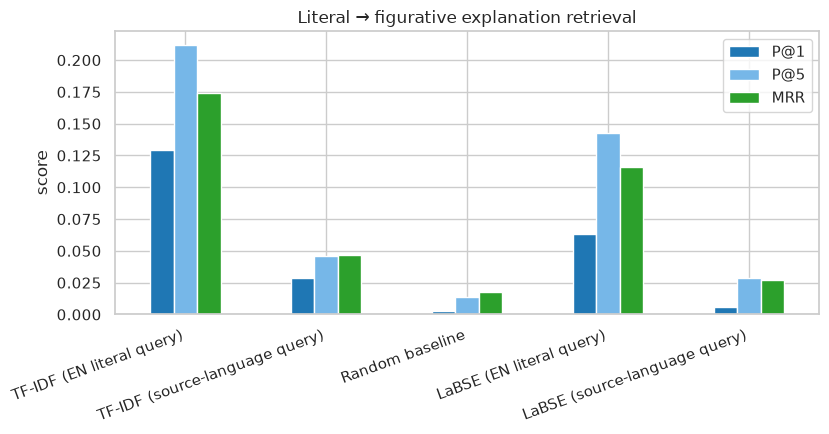

In [11]:
rdf = pd.DataFrame(res).T
fig, ax = plt.subplots(figsize=(8.5, 4.5))
rdf[['P@1', 'P@5', 'MRR']].plot.bar(ax=ax, color=['#1f77b4', '#76b7e8', '#2ca02c'])
ax.set_ylabel('score'); ax.set_title('Literal → figurative explanation retrieval')
plt.xticks(rotation=20, ha='right'); plt.tight_layout(); plt.show()

**Figure 6: Retrieval scores for TF-IDF and LaBSE, with English-literal queries and with source-language queries.**

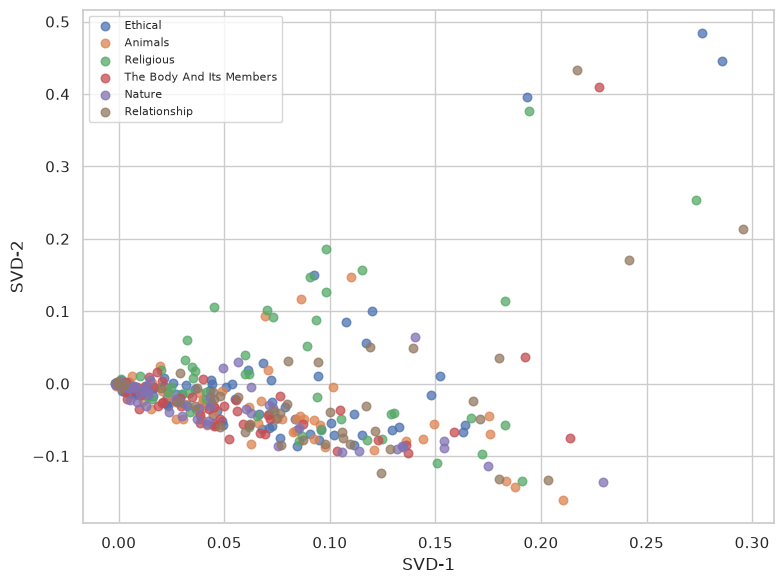

In [12]:
from sklearn.decomposition import TruncatedSVD
top6 = clf_df.theme.value_counts().head(6).index
sub = clf_df[clf_df.theme.isin(top6)].reset_index(drop=True)
X_all = TfidfVectorizer(stop_words='english', sublinear_tf=True).fit_transform(sub.literal_en)
xy = TruncatedSVD(2, random_state=42).fit_transform(X_all)
fig, ax = plt.subplots(figsize=(8, 6))
for b in top6:
    m = (sub.theme == b).values
    ax.scatter(xy[m, 0], xy[m, 1], label=b, alpha=0.75, s=38)
ax.legend(fontsize=8); ax.set_xlabel('SVD-1'); ax.set_ylabel('SVD-2')
plt.tight_layout(); plt.show()

**Figure 7: 2-D SVD projection of the literal translations for the six largest themes.**

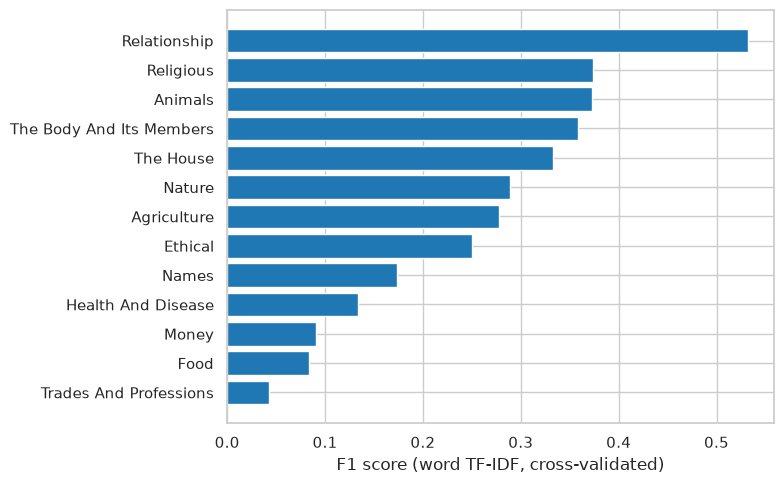

In [13]:
per_f1 = f1_score(y, pred_en, labels=sorted(y.unique()), average=None)
order = np.argsort(per_f1)
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(np.array(sorted(y.unique()))[order], per_f1[order], color='#1f77b4')
ax.set_xlabel('F1 score (word TF-IDF, cross-validated)')
plt.tight_layout()
plt.show()

**Figure 8: F1 per theme for the word TF-IDF classifier. Sections with recurring vocabulary of their own (Relationship, Religious, Animals) score highest, and the smallest sections (Money, Food, Trades) score lowest.**

In [14]:
import os
os.makedirs('report', exist_ok=True)
json.dump(metrics, open('report/PanelB_16_metrics_marathi.json', 'w'), indent=1)
print('metrics saved:', json.dumps(metrics)[:300])

metrics saved: {"n": 545, "n_comm": 349, "tok_src": 2670, "tok_en": 11915, "tok_comm": 5575, "voc_src": 2066, "voc_en": 6442, "len_src": 4.9, "len_en": 21.9, "len_comm": 10.2, "jac_own": 0.046, "jac_rand": 0.03, "clf_n": 466, "clf_k": 13, "maj_acc": 0.157, "maj_f1": 0.021, "acc_en": 0.307, "f1_en": 0.255, "acc_src


## 5. Discussion (Sahish Nagulwar)
Theme classification worked better than expected for a corpus this noisy. Over 466 proverbs and 13 book sections, word TF-IDF on the English literal translations reached accuracy 0.307 and macro-F1 0.255, and character n-grams on the romanized Marathi reached 0.217 and 0.187. Always predicting the largest section gives 0.157 and 0.021, so both models are well above the baseline. The ordering is the opposite of what the Assamese track found: here the word features on translations beat the character features on the source text. A plausible reason is length. Manwaring's romanized proverbs average only 4.9 tokens (the Assamese ones average 9.2), so there is not much for character n-grams to work with. The overlap measurement gave 0.046 against a proverb's own explanation and 0.030 against a random one, which is the same near-random gap as in the other tracks. Retrieval behaves like the Assamese track but at lower absolute numbers, since the explanations here average only 10.2 tokens. English-literal queries reach P@1 0.129, which is about 40 times the random baseline of 0.003. Marathi-form queries drop to 0.029. The LaBSE condition did not handle that drop on this data: English queries reach P@1 0.063, below TF-IDF, and Marathi queries 0.006, close to the random baseline. LaBSE expects Devanagari, and the 1899 romanization falls outside its training data. The main limitations are OCR noise in the 1899 print, the first-sentence heuristic used to separate translation from explanation, and the fact that section headings are only a rough label for figurative meaning.

## 6. Conclusion
A 545-proverb Marathi corpus with the book's own theme labels was built from Manwaring (1899). Themes can be predicted from the surface text well above the majority baseline (macro-F1 0.255 vs 0.021). The vocabulary overlap between the literal and figurative layers is close to random (0.046 vs 0.030). Retrieval of the correct explanation falls from P@1 0.129 with English queries to 0.029 with Marathi queries. LaBSE on the romanized text did not close that gap, so restoring the Devanagari text comes first.

## References (APA)
- Manwaring, A. (1899). *Marathi proverbs.* Oxford: Clarendon Press. https://archive.org/details/marathiproverbs00manwgoog
- Feng, F., Yang, Y., Cer, D., Arivazhagan, N., & Wang, W. (2022). Language-agnostic BERT sentence embedding. *Proceedings of ACL 2022*, 878–891.
- Khanuja, S., et al. (2021). MuRIL: Multilingual representations for Indian languages. *arXiv:2103.10730*.
- Kakwani, D., et al. (2020). IndicNLPSuite: Monolingual corpora, evaluation benchmarks and pre-trained multilingual language models for Indian languages. *Findings of EMNLP 2020*, 4948–4961.